# HW 2: Decision trees, pt 2.2

In [68]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score,\
    confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
import seaborn as sns
from matplotlib.legend_handler import HandlerLine2D
from sklearn import tree
import graphviz 

In [53]:
%load_ext pycodestyle_magic

%pylab inline
figsize(12, 8)

The pycodestyle_magic extension is already loaded. To reload it, use:
  %reload_ext pycodestyle_magic
Populating the interactive namespace from numpy and matplotlib


# Loading data from file

In [2]:
df_train = pd.read_csv("data/titanic_train.csv")

In [3]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,3,"Connolly, Miss. Kate",female,22.0,0,0,370373,7.7500,NaN,Q
1,1,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
2,2,0,1,"Ringhini, Mr. Sante",male,22.0,0,0,PC 17760,135.6333,NaN,C
3,3,0,2,"Abelson, Mr. Samuel",male,30.0,1,0,P/PP 3381,24.0000,NaN,C
4,4,0,3,"Charters, Mr. David",male,21.0,0,0,A/5. 13032,7.7333,NaN,Q


In [4]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,691.000000,691.000000,691.000000,560.000000,691.000000,691.000000,691.000000
mean,345.000000,0.370478,2.314038,29.471732,0.520984,0.366136,31.985865
std,199.618803,0.483282,0.836533,14.669983,1.078408,0.756007,48.639432
min,0.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,172.500000,0.000000,2.000000,20.000000,0.000000,0.000000,7.895800
50%,345.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,517.500000,1.000000,3.000000,38.000000,1.000000,0.000000,30.500000
max,690.000000,1.000000,3.000000,80.000000,8.000000,5.000000,512.329200


## See what's inside

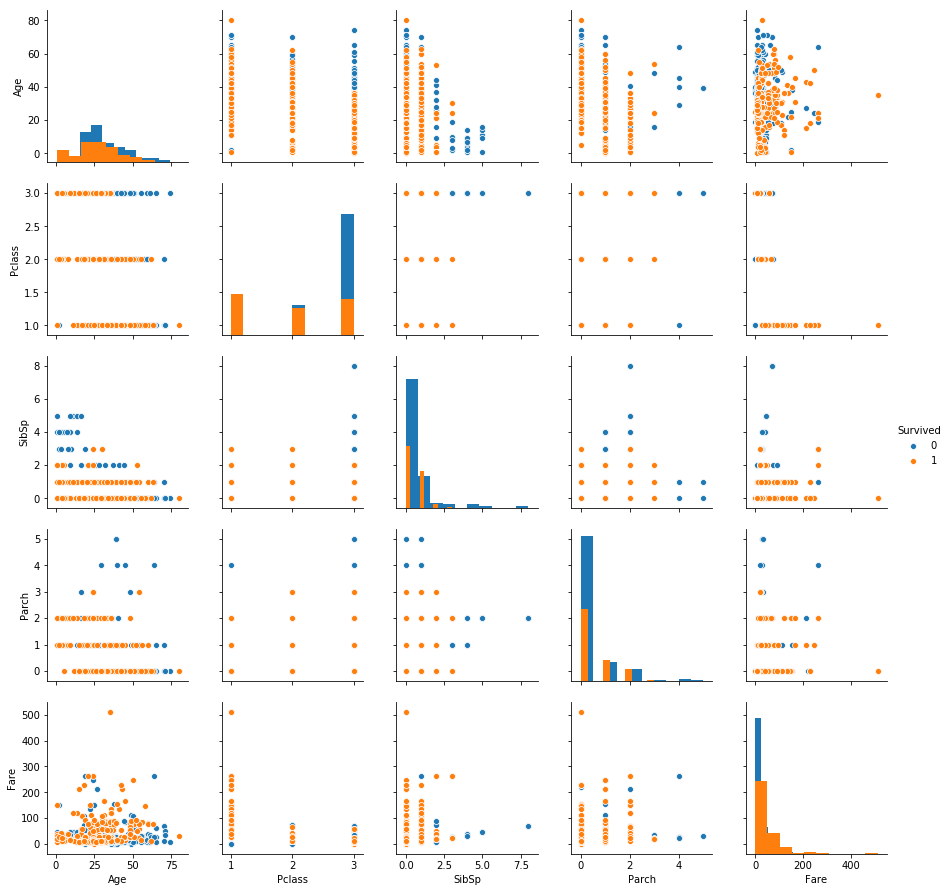

In [5]:
sns.pairplot(df_train, diag_kind='hist', 
             hue='Survived', vars=['Age', 'Pclass', 'SibSp', 'Parch', 'Fare'])

### Sorting out the data

In [6]:
df_train['Embarked'].unique()

array(['Q', 'S', 'C', nan], dtype=object)

In [7]:
df_train['Embarked'].value_counts(dropna=False)

S      498
C      133
Q       59
NaN      1
Name: Embarked, dtype: int64

In [8]:
df_train['Embarked'] = df_train['Embarked'].fillna('S')

Creating one-hot encoding of 'Embarked'

In [9]:
df_train = pd.concat([df_train, pd.get_dummies(df_train['Embarked'],
                                               prefix='port')], axis=1)

'Sex' is just 0 or 1

In [10]:
df_train['Sex'] = pd.Series(map(lambda x: 1 if x == 'male' else 0, df_train['Sex']))

In [11]:
df_train = df_train.drop(['Embarked', 'Cabin', 'Ticket'], axis=1)

Extracting 'Title' from "Name'

In [12]:
df_train['Title'] = df_train['Name'].str.split(' ').str[1]

In [13]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,port_C,port_Q,port_S,Title
0,0,1,3,"Connolly, Miss. Kate",0,22.0,0,0,7.7500,0,1,0,Miss.
1,1,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,30.0000,0,0,1,Miss.
2,2,0,1,"Ringhini, Mr. Sante",1,22.0,0,0,135.6333,1,0,0,Mr.
3,3,0,2,"Abelson, Mr. Samuel",1,30.0,1,0,24.0000,1,0,0,Mr.
4,4,0,3,"Charters, Mr. David",1,21.0,0,0,7.7333,0,1,0,Mr.


In [14]:
df_train = df_train.drop(['Name'],axis=1)

In [15]:
df_train['Title'].unique()

array(['Miss.', 'Mr.', 'Master.', 'Mrs.', 'Jonkheer.', 'Planke,', 'Col.',
       'Mme.', 'y', 'Billiard,', 'Impe,', 'Major.', 'Mlle.', 'Capt.',
       'the', 'Shawah,', 'Messemaeker,', 'Dr.', 'Walle,', 'Melkebeke,',
       'Rev.', 'Carlo,', 'Don.', 'Cruyssen,', 'Pelsmaeker,', 'der',
       'Steen,', 'Ms.', 'Velde,', 'Mulder,', 'Gordon,'], dtype=object)

In [16]:
df_train['Title'].value_counts()

Mr.             397
Miss.           134
Mrs.             87
Master.          33
Dr.               5
Rev.              5
y                 4
Impe,             2
Mlle.             2
Melkebeke,        1
Messemaeker,      1
Mulder,           1
Billiard,         1
Capt.             1
Shawah,           1
Carlo,            1
Mme.              1
Major.            1
Don.              1
Pelsmaeker,       1
Gordon,           1
Planke,           1
Velde,            1
Walle,            1
Ms.               1
Steen,            1
Jonkheer.         1
der               1
the               1
Col.              1
Cruyssen,         1
Name: Title, dtype: int64

Create a 'Rare' title

In [17]:
title_cts = df_train['Title'].value_counts()
rare_list = df_train['Title'].value_counts()[title_cts <= 5].index

df_train['Title'] = df_train['Title'].apply(lambda x: 'Rare'
                                            if x in rare_list else x)

In [18]:
df_train['Title'].value_counts()

Mr.        397
Miss.      134
Mrs.        87
Rare        40
Master.     33
Name: Title, dtype: int64

In [19]:
df_train = pd.concat([df_train, pd.get_dummies(df_train['Title'], prefix='title')],axis=1)

In [22]:
df_train.drop('Title', axis=1, inplace=True)

In [23]:
df_train = df_train.fillna(0)

In [24]:
df_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,port_C,port_Q,port_S,title_Master.,title_Miss.,title_Mr.,title_Mrs.,title_Rare
0,0,1,3,0,22.0,0,0,7.7500,0,1,0,0,1,0,0,0
1,1,1,1,0,19.0,0,0,30.0000,0,0,1,0,1,0,0,0
2,2,0,1,1,22.0,0,0,135.6333,1,0,0,0,0,1,0,0
3,3,0,2,1,30.0,1,0,24.0000,1,0,0,0,0,1,0,0
4,4,0,3,1,21.0,0,0,7.7333,0,1,0,0,0,1,0,0


### Defining train fv and labels. Also, dummy test

In [33]:
train_cols = (df_train.columns != 'Survived') &\
    (df_train.columns != 'PassengerId')

X_train, X_test, y_train, y_test = train_test_split(df_train.loc[:,
                                                                 train_cols],
                                                    df_train['Survived'],
                                                    test_size=0.3)

# Loading test data

In [34]:
df_test = pd.read_csv("data/titanic_test.csv")

In [35]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,691,1,"Spedden, Mrs. Frederic Oakley (Margaretta Corn...",female,40.0,1,1,16966,134.5000,E34,C
1,692,3,"Johansson, Mr. Karl Johan",male,31.0,0,0,347063,7.7750,NaN,S
2,693,1,"Hawksford, Mr. Walter James",male,NaN,0,0,16988,30.0000,D45,S
3,694,1,"Daniel, Mr. Robert Williams",male,27.0,0,0,113804,30.5000,NaN,S
4,695,3,"Chronopoulos, Mr. Apostolos",male,26.0,1,0,2680,14.4542,NaN,C


In [36]:
df_test['Embarked'] = df_test['Embarked'].fillna('S')
df_test = pd.concat([df_test, pd.get_dummies(df_test['Embarked'],
                                             prefix='port')], axis=1)
df_test['Sex'] = pd.Series(map(lambda x: 1 if x == 'male'
                             else 0, df_test['Sex']))
df_test['Title'] = df_test['Name'].str.split(' ').str[1]
df_test['Title'] = df_test['Title'].apply(lambda x: 'Rare' if x
                                          in rare_list else x)
df_test = pd.concat([df_test, pd.get_dummies(df_test['Title'],
                                          prefix='title')],axis=1)

In [37]:
df_test.drop(['Name', 'Ticket', 'Cabin',
              'Embarked', 'Title'], axis=1, inplace=True)

In [38]:
df_test = df_test.fillna(0)

In [39]:
df_test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,port_C,port_Q,port_S,title_Master.,title_Miss.,title_Mr.,title_Mrs.,title_Rare
0,691,1,0,40.0,1,1,134.5000,1,0,0,0,0,0,1,0
1,692,3,1,31.0,0,0,7.7750,0,0,1,0,0,1,0,0
2,693,1,1,0.0,0,0,30.0000,0,0,1,0,0,1,0,0
3,694,1,1,27.0,0,0,30.5000,0,0,1,0,0,1,0,0
4,695,3,1,26.0,1,0,14.4542,1,0,0,0,0,1,0,0


In [40]:
X_real_test = df_test.iloc[:, 1:]

## Trying to manually find the parameters

In [41]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
                       max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort=False,
                       random_state=None, splitter='best')

In [42]:
y_pred = model.predict_proba(X_test)[:, 1]

## ROC AUC metrics

In [46]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test,y_pred)
roc_auc = auc(false_positive_rate, true_positive_rate)
roc_auc

0.8161494993556062

## Testing the tree depth

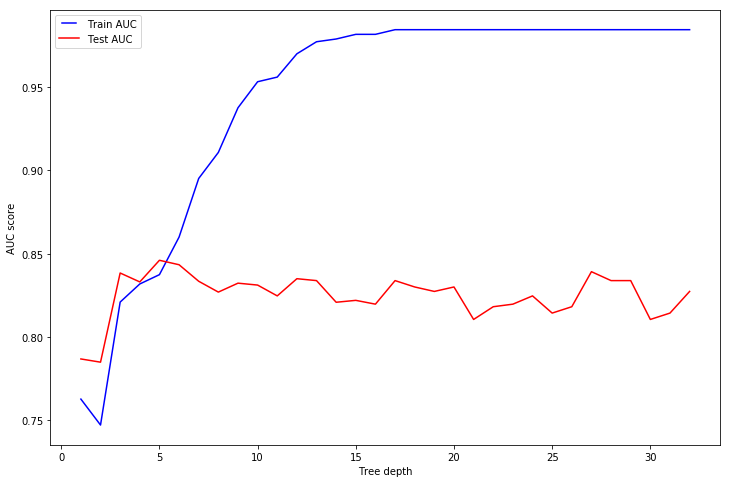

In [54]:
max_depths = np.linspace(1, 32, 32, endpoint=True)
train_results = []
test_results = []
for max_depth in max_depths:
    dt = DecisionTreeClassifier(max_depth=max_depth)
    dt.fit(X_train, y_train)
    train_pred = dt.predict(X_train)
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_train,
                                                                    train_pred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    # Add auc score to previous train results
    train_results.append(roc_auc)
    y_pred = dt.predict(X_test)
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test,
                                                                    y_pred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    # Add auc score to previous test results
    test_results.append(roc_auc)
line1, = plt.plot(max_depths, train_results, 'b', label='Train AUC')
line2, = plt.plot(max_depths, test_results, 'r', label='Test AUC')
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel('AUC score')
plt.xlabel('Tree depth')
plt.show()

### Choosing the region of [2,10] for the tree depth ^

## Same thing for min_samples_leaf

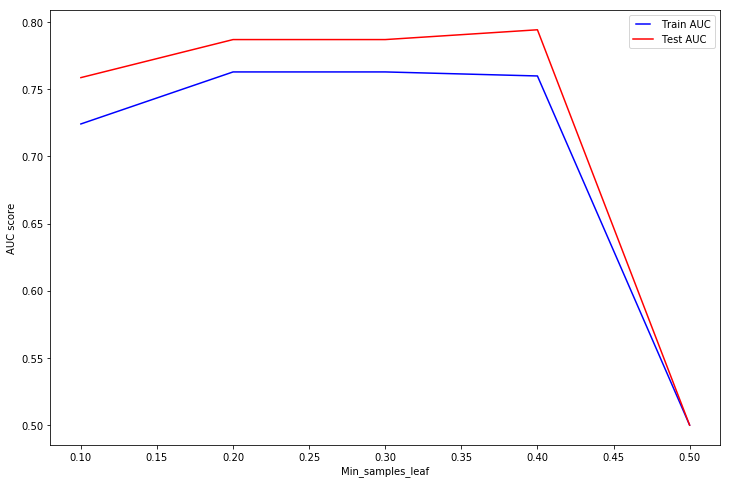

In [55]:
min_samples_leafs = np.linspace(0.1, 0.5, 5, endpoint=True)
train_results = []
test_results = []
for min_s in min_samples_leafs:
    dt = DecisionTreeClassifier(min_samples_leaf=min_s)
    dt.fit(X_train, y_train)
    train_pred = dt.predict(X_train)
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_train,
                                                                    train_pred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    # Add auc score to previous train results
    train_results.append(roc_auc)
    y_pred = dt.predict(X_test)
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test,
                                                                    y_pred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    # Add auc score to previous test results
    test_results.append(roc_auc)
line1, = plt.plot(min_samples_leafs, train_results, 'b', label='Train AUC')
line2, = plt.plot(min_samples_leafs, test_results, 'r', label='Test AUC')
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel('AUC score')
plt.xlabel('Min_samples_leaf')
plt.show()

### Makes sense to choose [0.1,0.4] ^

# GridSearchCV

In [56]:
params = {'criterion': ['gini','entropy'],
          'splitter': ['best','random'],
          'max_depth': list(range(2, 10)),
          'min_samples_leaf': np.linspace(0.1, 0.5, 10, endpoint=True)}

best_model = GridSearchCV(DecisionTreeClassifier(), params,
                          verbose=True, n_jobs=-1, cv=5,
                          scoring='roc_auc').fit(X_train, y_train)

print(best_model.best_params_)
print(best_model.best_score_)

Fitting 5 folds for each of 320 candidates, totalling 1600 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.8s


{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 0.1, 'splitter': 'best'}
0.8301870950328336


[Parallel(n_jobs=-1)]: Done 1600 out of 1600 | elapsed:    3.7s finished


In [57]:
best_model.best_estimator_.feature_importances_

array([0.25327779, 0.64302052, 0.02541224, 0.        , 0.        ,
       0.07828945, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ])

In [58]:
X_train.columns[best_model.best_estimator_.feature_importances_ > 0]

Index(['Pclass', 'Sex', 'Age', 'Fare'], dtype='object')

In [60]:
y_best_pred = best_model.best_estimator_.predict_proba(X_test)[:, 1]

In [61]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_best_pred)
roc_auc_test = auc(false_positive_rate, true_positive_rate)
roc_auc_test

0.8219490433230892

In [62]:
Y_real_pred = best_model.best_estimator_.predict_proba(X_real_test)[:, 1]

In [63]:
df_export = pd.concat([df_test.iloc[:, 0],
                       pd.Series(Y_real_pred)],
                      axis=1)

In [65]:
df_export.columns = ['PassengerId', 'Survived']

In [66]:
df_export.head()

,PassengerId,Survived
0,691,0.964706
1,692,0.141304
2,693,0.387755
3,694,0.235294
4,695,0.235294


In [67]:
df_export.to_csv('data/titanic_pred.csv')

# Visualizing the tree

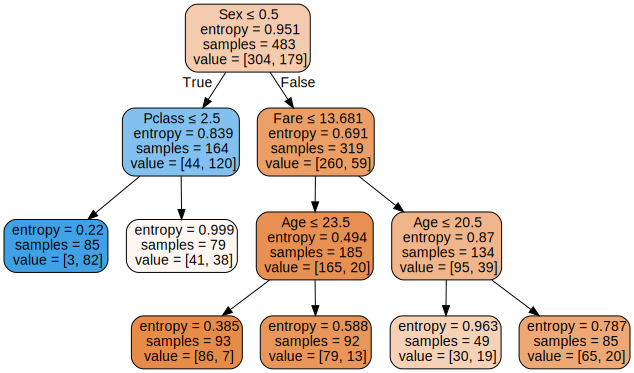

In [69]:
dot_data = tree.export_graphviz(best_model.best_estimator_,
                                out_file=None,
                                feature_names=X_train.columns,
                                filled=True, rounded=True,
                                special_characters=True)  
graph = graphviz.Source(dot_data)  
graph 

In [70]:
graph.render(filename='data/titanic_tree_nice')

'data/titanic_tree_nice.pdf'

## For default model parameters

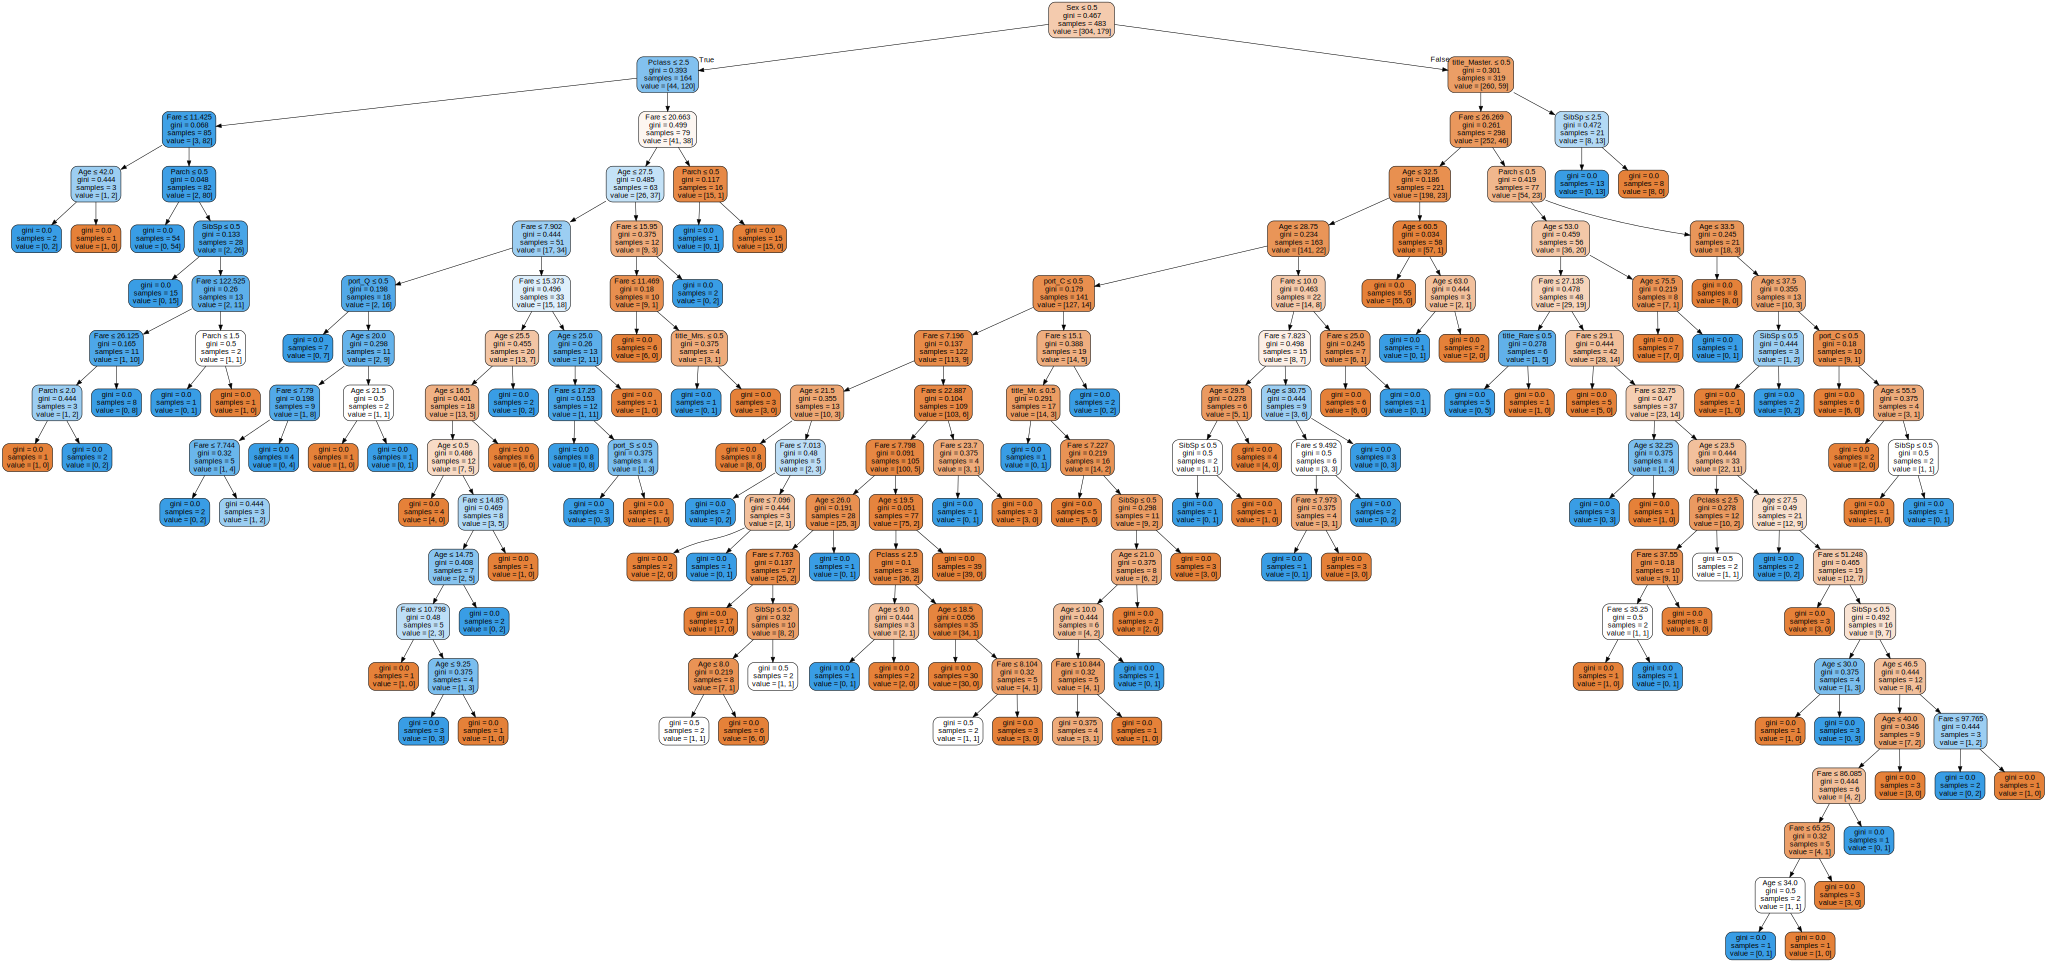

In [71]:
dot_data = tree.export_graphviz(model, out_file=None,
                                feature_names=X_train.columns,
                                filled=True, rounded=True,
                                special_characters=True)  
graph = graphviz.Source(dot_data)  
graph